## 1. 준비 (한글 폰트 + 라이브러리)

In [ ]:
!pip install koreanize-matplotlib -q

import numpy as np, pandas as pd
import lightgbm as lgb
from scipy.special import expit
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, recall_score, precision_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
import matplotlib.pyplot as plt
import koreanize_matplotlib   # 한글 폰트 자동 적용
print("준비 완료 ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 33.3 MB/s eta 0:00:00
준비 완료 ✅


## 2. 데이터 업로드
실행하면 파일 선택창이 떠요 → **전세보증대위변제현황_깡통라벨.xlsx** 선택

In [ ]:
from google.colab import files
up = files.upload()
DATA_PATH = list(up.keys())[0]
print("업로드:", DATA_PATH)

Saving 전세보증대위변제현황_깡통라벨.xlsx to 전세보증대위변제현황_깡통라벨.xlsx
업로드: 전세보증대위변제현황_깡통라벨.xlsx


## 3. 전처리
날짜 분리 · 이상치 윈저화 · 범주형 인코딩

In [ ]:
TARGET = "대위변제여부"; CAT = ["시도", "주택구분"]; SEED = 1

# Optuna 튜닝 결과(로컬에서 도출) — 파일 없이 바로 사용
BEST = {"learning_rate": 0.018985510051859406, "num_leaves": 104, "max_depth": 9,
        "min_child_samples": 97, "subsample": 0.7610750361344647,
        "colsample_bytree": 0.6632114899553294, "reg_alpha": 0.009506920466340139,
        "reg_lambda": 0.005510071891943215}

df = pd.read_excel(DATA_PATH).drop(columns=["일련번호"])
dt = pd.to_datetime(df["보증완료월"])
df["보증완료연도"] = dt.dt.year
df["보증완료월"] = dt.dt.month
df = df.drop(columns=["깡통전세여부"])   # 깡통지수와 중복이라 제외

# 이상치 상하위 0.5% 윈저화 (주택가액 2.68조 등 오류 완화)
for c in ["주택가액", "임대보증금액", "선순위채권금액", "평균보증금인상률", "시세대비보증금비율", "거래량"]:
    lo, hi = df[c].quantile(0.005), df[c].quantile(0.995)
    df[c] = df[c].clip(lo, hi)
for c in CAT:
    df[c] = df[c].astype("category")

X = df.drop(columns=[TARGET]); y = df[TARGET].astype(int)
print(f"데이터 {X.shape} | 양성(대위변제) {int(y.sum())}건 ({y.mean()*100:.1f}%)")

데이터 (50054, 19) | 양성(대위변제) 3777건 (7.5%)


## 4. 클래스 균형화 (언더샘플 50:50)
불균형(7.5%)이라 음성을 양성 수만큼 랜덤 추출해 1:1로 맞춤

In [ ]:
pos = y[y == 1].index
neg = y[y == 0].sample(n=len(pos), random_state=SEED).index
bal = pos.union(neg)
Xb, yb = X.loc[bal], y.loc[bal]
print(f"균형화 후 {len(yb)}건 (양성 {int(yb.sum())} / 음성 {int((yb==0).sum())})")

균형화 후 7554건 (양성 3777 / 음성 3777)


## 5. 학습/평가 분리 (stratify)

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(Xb, yb, test_size=0.2, random_state=SEED, stratify=yb)
print("train", X_tr.shape, "/ test", X_te.shape)

train (6043, 19) / test (1511, 19)


## 6. LightGBM 학습

In [ ]:
model = lgb.LGBMClassifier(n_estimators=400, random_state=SEED, verbose=-1, **BEST)
model.fit(X_tr, y_tr, categorical_feature=CAT)
prob = model.predict_proba(X_te)[:, 1]
pred = (prob >= 0.5).astype(int)
print("학습 완료 ✅")

학습 완료 ✅


## 7. 성능 평가 (수치)

In [ ]:
print("F1       ", round(f1_score(y_te, pred), 3))
print("Recall   ", round(recall_score(y_te, pred), 3))
print("Precision", round(precision_score(y_te, pred), 3))
print("ROC-AUC  ", round(roc_auc_score(y_te, prob), 3))
print()
print(classification_report(y_te, pred, target_names=["정상", "대위변제"], digits=3))

F1        0.814
Recall    0.81
Precision 0.819
ROC-AUC   0.894

              precision    recall  f1-score   support

          정상      0.812     0.821     0.816       755
        대위변제      0.819     0.810     0.814       756

    accuracy                          0.815      1511
   macro avg      0.815     0.815     0.815      1511
weighted avg      0.815     0.815     0.815      1511



## 8. 혼동행렬 (Confusion Matrix) 이미지

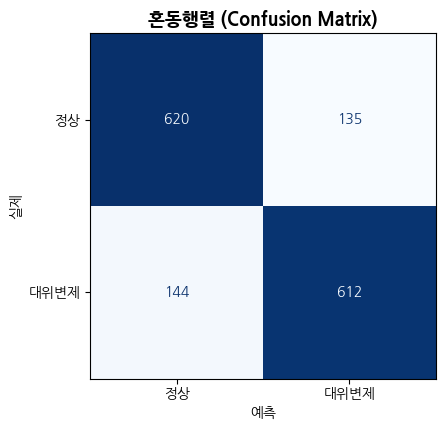

In [ ]:
cm = confusion_matrix(y_te, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["정상", "대위변제"])
fig, ax = plt.subplots(figsize=(5.2, 4.4))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("혼동행렬 (Confusion Matrix)", fontsize=13, weight="bold")
ax.set_xlabel("예측"); ax.set_ylabel("실제")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=130); plt.show()

## 9. SHAP — 전역 위험요인 중요도
LightGBM 내장 TreeSHAP(shap 라이브러리 불필요, 값 동일)

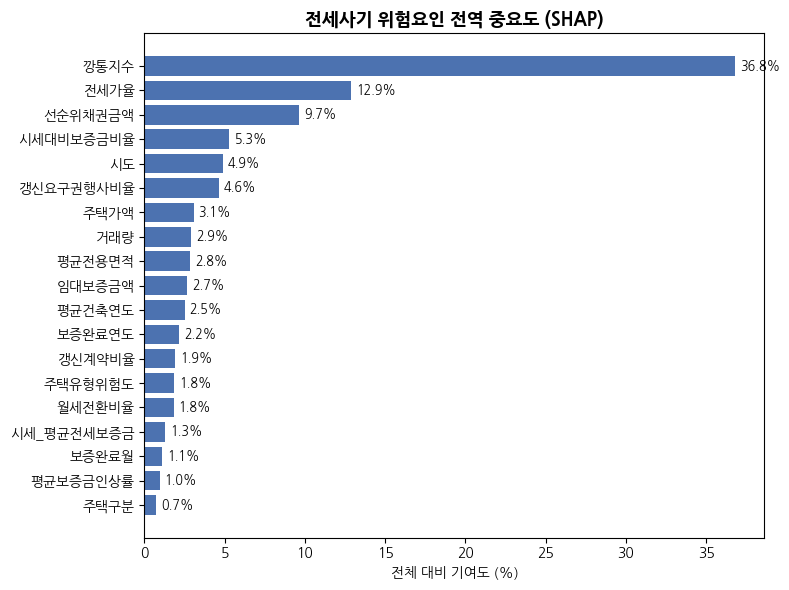

In [ ]:
contrib = model.booster_.predict(X_te, pred_contrib=True)
sv, base = contrib[:, :-1], contrib[0, -1]
feat = list(X.columns)

g = pd.Series(np.abs(sv).mean(0), index=feat).sort_values()
gp = g / g.sum() * 100
plt.figure(figsize=(8, 6))
plt.barh(gp.index, gp.values, color="#4c72b0")
for i, v in enumerate(gp.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.title("전세사기 위험요인 전역 중요도 (SHAP)", fontsize=13, weight="bold")
plt.xlabel("전체 대비 기여도 (%)")
plt.tight_layout(); plt.savefig("shap_global.png", dpi=130); plt.show()

## 10. SHAP — 개별 매물 설명 (Waterfall)
위험도가 가장 높은 매물의 요인별 기여

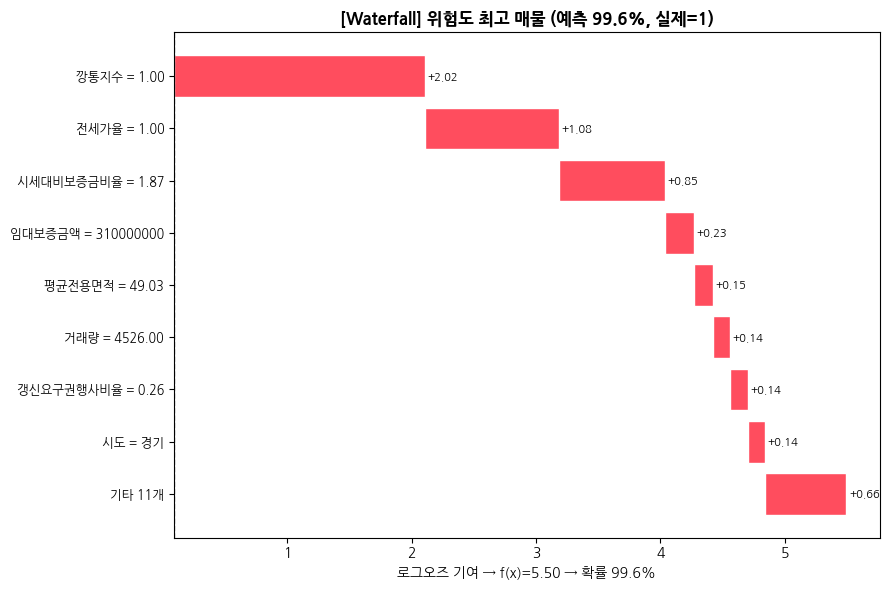

In [ ]:
RED, BLUE = "#ff4d5e", "#3b8be0"
i = int(np.argmax(prob)); sv_i, xr = sv[i], X_te.iloc[i]
order = np.argsort(np.abs(sv_i))[::-1]; TOPN = 8
top = order[:TOPN]; rest = sv_i[order[TOPN:]].sum()
labels = [f"{feat[j]} = {xr[feat[j]]:.2f}" if isinstance(xr[feat[j]], float) else f"{feat[j]} = {xr[feat[j]]}" for j in top]
vals = [sv_i[j] for j in top]
if abs(rest) > 1e-9: labels.append(f"기타 {len(feat)-TOPN}개"); vals.append(rest)
fx = base + sv_i.sum()

plt.figure(figsize=(9, 6)); cum = base; yp = np.arange(len(vals))[::-1]
for yy, (lab, v) in zip(yp, zip(labels, vals)):
    plt.barh(yy, v, left=cum, color=RED if v > 0 else BLUE, edgecolor="white")
    plt.text(cum + v + (0.02 if v > 0 else -0.02), yy, f"{v:+.2f}", va="center",
             ha="left" if v > 0 else "right", fontsize=8); cum += v
plt.yticks(yp, labels, fontsize=9); plt.axvline(base, color="gray", ls="--", lw=1)
plt.title(f"[Waterfall] 위험도 최고 매물 (예측 {prob[i]:.1%}, 실제={y_te.iloc[i]})", fontsize=12, weight="bold")
plt.xlabel(f"로그오즈 기여 → f(x)={fx:.2f} → 확률 {expit(fx):.1%}")
plt.tight_layout(); plt.savefig("shap_waterfall.png", dpi=130); plt.show()

## 11. SHAP — Force Plot (가로 누적)
빨강=위험↑, 파랑=위험↓

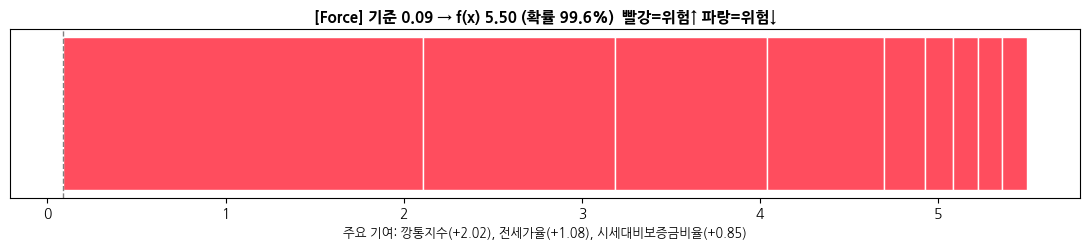

In [ ]:
plt.figure(figsize=(11, 2.6)); ax = plt.gca()
pieces = [(feat[j], sv_i[j]) for j in top] + ([("기타", rest)] if abs(rest) > 1e-9 else [])
left = base
for _, v in sorted([p for p in pieces if p[1] < 0], key=lambda t: t[1]):
    ax.barh(0, v, left=left, color=BLUE, edgecolor="white"); left += v
bl = left; right = base
for _, v in sorted([p for p in pieces if p[1] >= 0], key=lambda t: -t[1]):
    ax.barh(0, v, left=right, color=RED, edgecolor="white"); right += v
ax.axvline(base, color="gray", ls="--", lw=1); ax.set_yticks([])
ax.set_xlim(min(bl, base) - 0.3, max(right, base) + 0.3)
ax.set_title(f"[Force] 기준 {base:.2f} → f(x) {fx:.2f} (확률 {expit(fx):.1%})  빨강=위험↑ 파랑=위험↓", fontsize=11, weight="bold")
ax.set_xlabel("주요 기여: " + ", ".join(f"{feat[j]}({sv_i[j]:+.2f})" for j in top[:3]), fontsize=9)
plt.tight_layout(); plt.savefig("shap_force.png", dpi=130); plt.show()

## 12. 매물별 위험도 점수 저장

In [ ]:
out = X_te.copy(); out["실제_대위변제여부"] = y_te.values; out["위험도점수"] = prob
out = out.sort_values("위험도점수", ascending=False)
out.to_csv("risk_scores.csv", index=False, encoding="utf-8-sig")
print("저장: risk_scores.csv / confusion_matrix.png / shap_global.png / shap_waterfall.png / shap_force.png")
out[["실제_대위변제여부", "위험도점수"]].head(10)

저장: risk_scores.csv / confusion_matrix.png / shap_global.png / shap_waterfall.png / shap_force.png


,실제_대위변제여부,위험도점수
2133,1,0.995913
46547,1,0.993957
46433,1,0.993782
41292,1,0.993261
41142,1,0.993108
2272,1,0.993092
46463,1,0.992452
2120,1,0.992244
41030,1,0.991770
41015,1,0.991476


## 13. SHAP 라이브러리 공식 시각화 (summary · force)
Colab에선 shap 라이브러리가 정상 설치됩니다.
값은 LightGBM 내장 TreeSHAP과 동일하되, **shap의 공식 그래프**로 그립니다.

In [ ]:
!pip install shap -q
import shap

# 신뢰되는 LightGBM TreeSHAP 값을 그대로 사용 (shap_values() 버전 이슈 회피)
contrib = model.booster_.predict(X_te, pred_contrib=True)
sv = contrib[:, :-1]          # 각 피처의 SHAP 기여도
base_val = contrib[0, -1]     # 기준값(expected value)
X_num = X_te.copy()
for c in CAT:
    X_num[c] = X_num[c].cat.codes   # 범주형 → 색상표시용 코드값
feat = list(X_te.columns)
print("SHAP 값 준비 완료:", sv.shape)

SHAP 값 준비 완료: (1511, 19)


### 13-1. Summary Plot (beeswarm)
피처별로 위험도에 준 영향의 분포. 점이 오른쪽=위험↑, 색 빨강=피처값 큼.

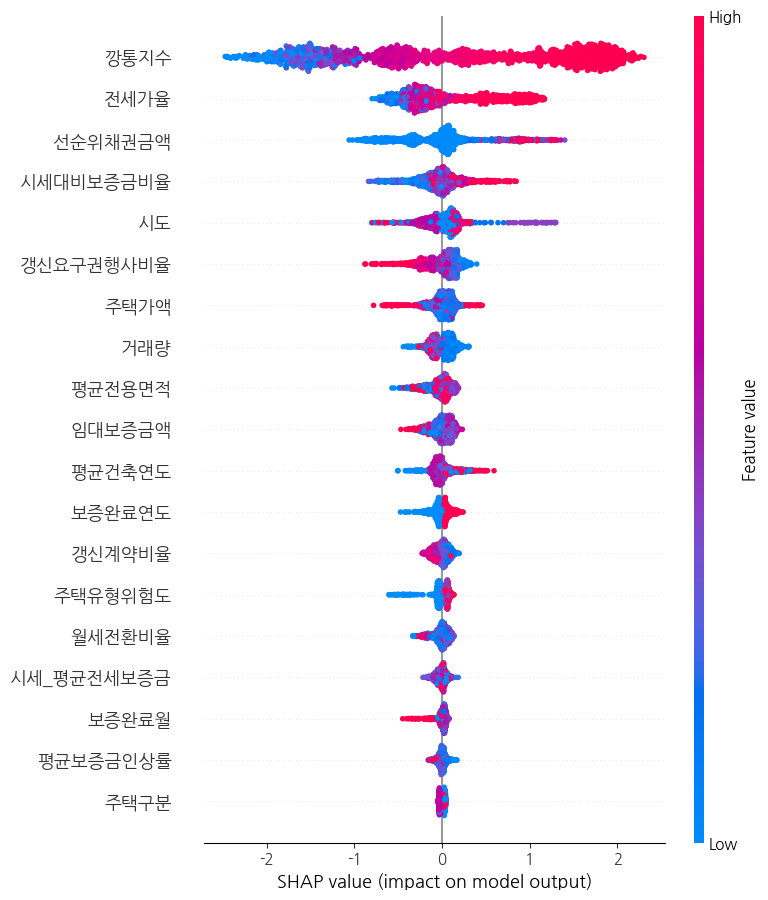

In [ ]:
shap.summary_plot(sv, X_num.values, feature_names=feat, show=False)
plt.tight_layout(); plt.savefig("shap_summary.png", dpi=130, bbox_inches="tight"); plt.show()

### 13-2. Summary Plot (bar) — 전역 중요도 막대

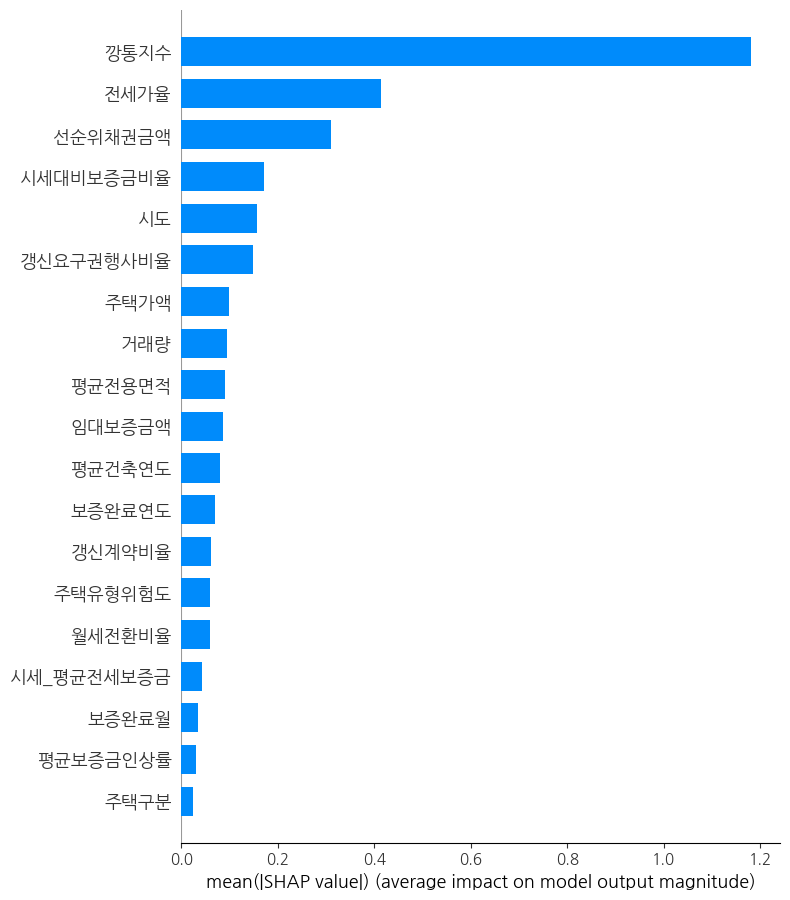

In [ ]:
shap.summary_plot(sv, X_num.values, feature_names=feat, plot_type="bar", show=False)
plt.tight_layout(); plt.savefig("shap_summary_bar.png", dpi=130, bbox_inches="tight"); plt.show()

### 13-3. Force Plot (위험도 최고 매물 1건)
한 매물의 위험 요인: 빨강=위험↑, 파랑=위험↓

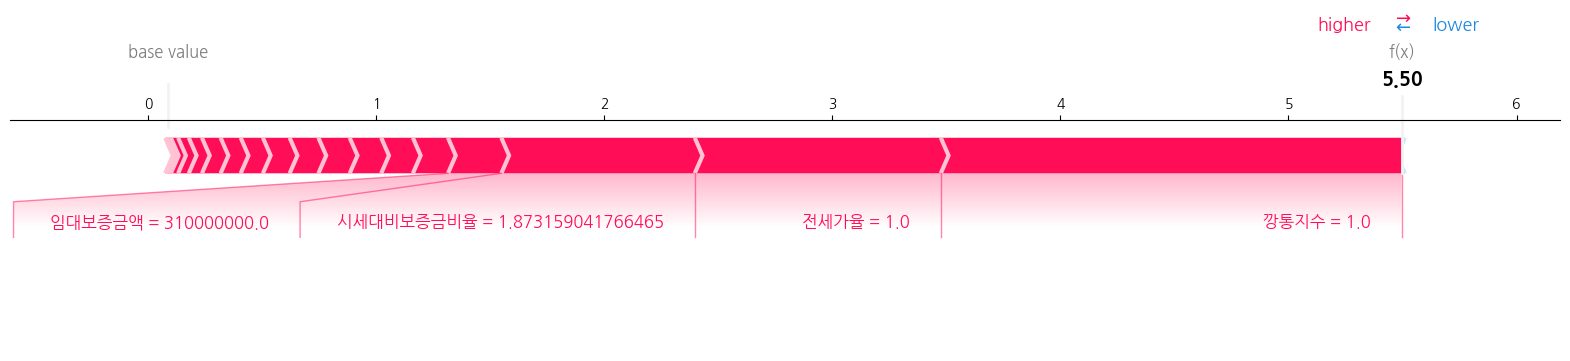

매물 예측 위험도 99.6% / 실제 대위변제=1


In [ ]:
i = int(np.argmax(prob))
shap.force_plot(base_val, sv[i], X_num.iloc[i].values, feature_names=feat,
                matplotlib=True, show=False)
plt.savefig("shap_force_lib.png", dpi=130, bbox_inches="tight"); plt.show()
print(f"매물 예측 위험도 {prob[i]:.1%} / 실제 대위변제={y_te.iloc[i]}")

In [ ]:
# ================================================================
#  🏠 전세사기 위험 예측 데모 (Gradio) — 설명 강화판
#  6개 입력 → 위험도 점수 + 등급 + SHAP 그래프 + 요인별 상세 설명 + 권고
#  * 먼저 앞 셀에서 '전세보증대위변제현황_깡통라벨.xlsx' 업로드 → DATA_PATH 존재해야 함
# ================================================================
!pip install gradio -q
import numpy as np, pandas as pd
import lightgbm as lgb
import gradio as gr
import matplotlib.pyplot as plt
import koreanize_matplotlib

# from google.colab import files; DATA_PATH = list(files.upload().keys())[0]

CAT = ["시도", "주택구분"]
MARKET = ["시세_평균전세보증금", "월세전환비율", "평균보증금인상률", "갱신계약비율",
          "갱신요구권행사비율", "평균건축연도", "평균전용면적", "거래량"]

# ---------- 데이터·모델·조회테이블 ----------
df = pd.read_excel(DATA_PATH).drop(columns=["일련번호"])
dt = pd.to_datetime(df["보증완료월"]); df["보증완료연도"] = dt.dt.year; df["보증완료월"] = dt.dt.month
raw = df.copy(); df = df.drop(columns=["깡통전세여부"])
for c in ["주택가액", "임대보증금액", "선순위채권금액", "평균보증금인상률", "시세대비보증금비율", "거래량"]:
    lo, hi = df[c].quantile(0.005), df[c].quantile(0.995); df[c] = df[c].clip(lo, hi)
for c in CAT: df[c] = df[c].astype("category")
X = df.drop(columns=["대위변제여부"]); y = df["대위변제여부"].astype(int)
Xcols = list(X.columns); SIDO_CATS = X["시도"].cat.categories; HOUSE_CATS = X["주택구분"].cat.categories
pos = y[y == 1].index; neg = y[y == 0].sample(n=len(pos), random_state=1).index
model = lgb.LGBMClassifier(n_estimators=400, random_state=1, verbose=-1, learning_rate=0.019,
    num_leaves=104, max_depth=9, min_child_samples=97, subsample=0.761, colsample_bytree=0.663,
    reg_alpha=0.0095, reg_lambda=0.0055)
model.fit(X.loc[pos.union(neg)], y.loc[pos.union(neg)], categorical_feature=CAT)
market_lut = raw.groupby(["시도", "주택구분"])[MARKET].mean()
risk_lut = raw.groupby("주택구분")["주택유형위험도"].first()
SIDO_LIST, HOUSE_LIST = list(SIDO_CATS), list(HOUSE_CATS)

# ---------- 주택가액 자동조회 (매매 실거래가 API) ----------
import os
import requests, datetime
import xml.etree.ElementTree as ET
TRADE_KEY = os.environ.get("TRADE_KEY", "")  # 실행 전 환경변수로 설정 (국토부 실거래가 API 인증키)
TRADE_URL = {
    "아파트":   "http://apis.data.go.kr/1613000/RTMSDataSvcAptTradeDev/getRTMSDataSvcAptTradeDev",
    "연립다세대": "http://apis.data.go.kr/1613000/RTMSDataSvcRHTrade/getRTMSDataSvcRHTrade",
    "오피스텔":  "http://apis.data.go.kr/1613000/RTMSDataSvcOffiTrade/getRTMSDataSvcOffiTrade",
    "단독다가구": "http://apis.data.go.kr/1613000/RTMSDataSvcSHTrade/getRTMSDataSvcSHTrade",
}
HOUSE2TRADE = {"아파트": "아파트", "다세대주택": "연립다세대", "연립주택": "연립다세대",
               "오피스텔": "오피스텔", "다가구주택": "단독다가구", "다중주택": "단독다가구",
               "단독주택": "단독다가구", "주상복합": "아파트"}
NAME_FIELD = {"아파트": "aptNm", "연립다세대": "mhouseNm", "오피스텔": "offiNm", "단독다가구": None}
SGG = {"서울": {"종로구": "11110", "중구": "11140", "용산구": "11170", "성동구": "11200", "광진구": "11215", "동대문구": "11230", "중랑구": "11260", "성북구": "11290", "강북구": "11305", "도봉구": "11320", "노원구": "11350", "은평구": "11380", "서대문구": "11410", "마포구": "11440", "양천구": "11470", "강서구": "11500", "구로구": "11530", "금천구": "11545", "영등포구": "11560", "동작구": "11590", "관악구": "11620", "서초구": "11650", "강남구": "11680", "송파구": "11710", "강동구": "11740"}, "전남": {"목포시": "12110", "여수시": "12130", "순천시": "12150", "나주시": "12170", "광양시": "12190"}, "광주": {"광주동구": "12210", "광주서구": "12240", "광주남구": "12270", "광주북구": "12300", "광주광산구": "12330"}, "부산": {"중구": "26110", "서구": "26140", "동구": "26170", "영도구": "26200", "부산진구": "26230", "동래구": "26260", "남구": "26290", "북구": "26320", "해운대구": "26350", "사하구": "26380", "금정구": "26410", "강서구": "26440", "연제구": "26470", "수영구": "26500", "사상구": "26530", "기장군": "26710"}, "대구": {"중구": "27110", "동구": "27140", "서구": "27170", "남구": "27200", "북구": "27230", "수성구": "27260", "달서구": "27290", "달성군": "27710"}, "인천": {"중구": "28110", "중구영종출장": "28115", "중구용유출장": "28116", "동구": "28140", "미추홀구": "28177", "연수구": "28185", "남동구": "28200", "부평구": "28237", "계양구": "28245", "서구": "28260", "서구검단출장": "28265", "강화군": "28710", "옹진군": "28720"}, "대전": {"동구": "30110", "중구": "30140", "서구": "30170", "유성구": "30200", "대덕구": "30230"}, "울산": {"중구": "31110", "남구": "31140", "동구": "31170", "북구": "31200", "울주군": "31710"}, "세종": {"세종시": "36110"}, "경기": {"수원시": "41110", "수원시 장안구": "41111", "수원시 권선구": "41113", "수원시 팔달구": "41115", "수원시 영통구": "41117", "성남시": "41130", "성남시 수정구": "41131", "성남시 중원구": "41133", "성남시 분당구": "41135", "의정부시": "41150", "안양시": "41170", "안양시 만안구": "41171", "안양시 동안구": "41173", "부천시": "41190", "광명시": "41210", "평택시": "41220", "동두천시": "41250", "안산시": "41270", "안산시 상록구": "41271", "안산시 단원구": "41273", "고양시": "41280", "고양시 덕양구": "41281", "고양시 일산동구": "41285", "고양시 일산서구": "41287", "과천시": "41290", "구리시": "41310", "남양주시": "41360", "오산시": "41370", "시흥시": "41390", "군포시": "41410", "의왕시": "41430", "하남시": "41450", "용인시": "41460", "용인시 처인구": "41461", "용인시 기흥구": "41463", "용인시 수지구": "41465", "파주시": "41480", "이천시": "41500", "안성시": "41550", "김포시": "41570", "화성시": "41590", "광주시": "41610", "양주시": "41630", "포천시": "41650", "여주시": "41670", "연천군": "41800", "가평군": "41820", "양평군": "41830"}, "충북": {"청주시": "43110", "청주시 상당구": "43111", "청주시 서원구": "43112", "청주시 흥덕구": "43113", "청주시 청원구": "43114", "충주시": "43130", "제천시": "43150", "보은군": "43720", "옥천군": "43730", "영동군": "43740", "증평군": "43745", "진천군": "43750", "괴산군": "43760", "음성군": "43770", "단양군": "43800"}, "충남": {"천안시": "44130", "천안시 동남구": "44131", "천안시 서북구": "44133", "공주시": "44150", "보령시": "44180", "아산시": "44200", "서산시": "44210", "논산시": "44230", "계룡시": "44250", "당진시": "44270", "금산군": "44710", "부여군": "44760", "서천군": "44770", "청양군": "44790", "홍성군": "44800", "예산군": "44810", "태안군": "44825"}, "경북": {"포항시": "47110", "포항시 남구": "47111", "포항시 북구": "47113", "경주시": "47130", "김천시": "47150", "안동시": "47170", "구미시": "47190", "영주시": "47210", "영천시": "47230", "상주시": "47250", "문경시": "47280", "경산시": "47290", "군위군": "47720", "의성군": "47730", "청송군": "47750", "영양군": "47760", "영덕군": "47770", "청도군": "47820", "고령군": "47830", "성주군": "47840", "칠곡군": "47850", "예천군": "47900", "봉화군": "47920", "울진군": "47930", "울릉군": "47940"}, "경남": {"창원시": "48120", "창원시 의창구": "48121", "창원시 성산구": "48123", "창원시 마산합포구": "48125", "창원시 마산회원구": "48127", "창원시 진해구": "48129", "진주시": "48170", "통영시": "48220", "사천시": "48240", "사천남양출장": "48245", "김해시": "48250", "밀양시": "48270", "거제시": "48310", "양산시": "48330", "의령군": "48720", "함안군": "48730", "창녕군": "48740", "고성군": "48820", "남해군": "48840", "하동군": "48850", "산청군": "48860", "함양군": "48870", "거창군": "48880", "합천군": "48890"}, "제주": {"제주시": "50110", "서귀포시": "50130"}, "강원": {"춘천시": "51110", "원주시": "51130", "강릉시": "51150", "동해시": "51170", "태백시": "51190", "속초시": "51210", "삼척시": "51230", "홍천군": "51720", "횡성군": "51730", "영월군": "51750", "평창군": "51760", "정선군": "51770", "철원군": "51780", "화천군": "51790", "양구군": "51800", "인제군": "51810", "고성군": "51820", "양양군": "51830"}, "전북": {"전주시 완산구": "52111", "전주시 덕진구": "52113", "군산시": "52130", "익산시": "52140", "정읍시": "52180", "남원시": "52190", "김제시": "52210", "완주군": "52710", "진안군": "52720", "무주군": "52730", "장수군": "52740", "임실군": "52750", "순창군": "52770", "고창군": "52790", "부안군": "52800"}}

# ---------- 주소 한 줄 자동입력 (행안부 주소검색 API + 텍스트 파싱 폴백) ----------
JUSO_KEY = os.environ.get("JUSO_KEY", "")  # 실행 전 환경변수로 설정 (행안부 주소검색 API 인증키)
SIDO_ALIAS = {"서울특별시":"서울","서울시":"서울","서울":"서울","부산광역시":"부산","부산":"부산",
  "대구광역시":"대구","대구":"대구","인천광역시":"인천","인천":"인천","광주광역시":"광주","광주":"광주",
  "대전광역시":"대전","대전":"대전","울산광역시":"울산","울산":"울산","세종특별자치시":"세종","세종시":"세종","세종":"세종",
  "경기도":"경기","경기":"경기","강원특별자치도":"강원","강원도":"강원","강원":"강원",
  "충청북도":"충북","충북":"충북","충청남도":"충남","충남":"충남",
  "전북특별자치도":"전북","전라북도":"전북","전북":"전북","전라남도":"전남","전남":"전남",
  "경상북도":"경북","경북":"경북","경상남도":"경남","경남":"경남",
  "제주특별자치도":"제주","제주도":"제주","제주":"제주"}
_TYPE2HOUSE = {"아파트": "아파트", "연립다세대": "다세대주택", "오피스텔": "오피스텔"}
_PREF2SIDO = {"11":"서울","26":"부산","27":"대구","28":"인천","30":"대전","31":"울산","36":"세종",
              "41":"경기","43":"충북","44":"충남","47":"경북","48":"경남","50":"제주","51":"강원","52":"전북"}
_GWANGJU = {"12210", "12240", "12270", "12300", "12330"}
_CODE2NAME = {cd: nm for d in SGG.values() for nm, cd in d.items()}


def _code2sido(lawd):
    return _PREF2SIDO.get(lawd[:2]) or ("광주" if lawd in _GWANGJU else "전남")


def _clean_bname(nm):
    nm = (nm or "").strip()
    for suf in ("아파트", "오피스텔"):
        if nm.endswith(suf) and len(nm) > len(suf):
            nm = nm[: -len(suf)]
    return nm.strip()


def juso_search(addr):
    """행안부 주소검색 → (lawd5, 건물명, 표기주소) 또는 None"""
    try:
        r = requests.get("https://business.juso.go.kr/addrlink/addrLinkApi.do",
                         params={"confmKey": JUSO_KEY, "currentPage": 1, "countPerPage": 1,
                                 "keyword": addr, "resultType": "json"}, timeout=8)
        res = r.json()["results"]
        if res["common"]["errorCode"] != "0" or not res.get("juso"):
            return None
        it = res["juso"][0]
        return it["admCd"][:5], it.get("bdNm", ""), it.get("roadAddr", "")
    except Exception:
        return None


def _parse_text(addr):
    """폴백: 내장 사전 기반 텍스트 파싱 → (sido, sgg_name, lawd5, 남은토큰) 또는 None"""
    import re
    toks = addr.split()
    sido = next((SIDO_ALIAS[t] for t in toks if t in SIDO_ALIAS), None)
    for sd in ([sido] if sido else list(SGG.keys())):
        for name in sorted(SGG[sd], key=len, reverse=True):
            parts = name.split()
            stripped = name[2:] if name.startswith(("광주", "전남")) and len(name) > 2 else name
            if all(p in toks for p in parts) or stripped in toks:
                used = set(parts) | {stripped}
                bname = " ".join(t for t in toks if t not in SIDO_ALIAS and t not in used
                                 and not re.fullmatch(r"[0-9-]+", t)
                                 and not re.search(r"(동|읍|면|리|로|길|가)$", t))
                return sd, name, SGG[sd][name], _clean_bname(bname)
    return None


def _search_trades(lawd, bname):
    """단지명을 3종 매매 API에 교차 검색 → (유형, 가격리스트)"""
    best_type, best_prices = None, []
    for trade in ("아파트", "연립다세대", "오피스텔"):
        url, namef = TRADE_URL[trade], NAME_FIELD[trade]
        prices = []
        d = datetime.date.today().replace(day=1)
        for _ in range(3):
            ymd = f"{d.year}{d.month:02d}"
            for _try in range(3):
                try:
                    r = requests.get(url, params={"serviceKey": TRADE_KEY, "LAWD_CD": lawd,
                                     "DEAL_YMD": ymd, "pageNo": "1", "numOfRows": "1000"}, timeout=15)
                    if r.status_code != 200:
                        continue
                    root = ET.fromstring(r.content)
                    for it in root.findall(".//item"):
                        nm = (it.findtext(namef) or "")
                        amt = (it.findtext("dealAmount") or "").replace(",", "").strip()
                        if amt and bname in nm:
                            prices.append(float(amt) * 10000)
                    break
                except (requests.RequestException, ET.ParseError):
                    continue
            d = (d - datetime.timedelta(days=1)).replace(day=1)
        if len(prices) > len(best_prices):
            best_type, best_prices = trade, prices
    return best_type, best_prices


def smart_fill(addr):
    """주소 한 줄 → 시도/주택구분/주택가액 자동입력 (주소API 우선, 파싱 폴백)"""
    addr = (addr or "").strip()
    if not addr:
        return [gr.update()] * 3 + ["⚠️ 주소를 입력하세요. 예: 서울 강남구 테헤란로 152 / 강남구 은마아파트"]

    lawd = bname = sgg_label = None
    via = ""
    j = juso_search(addr)
    if j:
        lawd, bdnm, road = j
        sgg_label = _CODE2NAME.get(lawd, "")
        bname = _clean_bname(bdnm)
        via = f"🧭 {road}"
    else:
        p = _parse_text(addr)
        if not p:
            return [gr.update()] * 3 + ["⚠️ 주소를 인식하지 못했어요. 예: 서울 강남구 은마아파트"]
        _, sgg_label, lawd, bname = p
        via = "🔤 텍스트 인식(주소API 미응답)"

    sido = _code2sido(lawd)
    upd_sido = gr.update(value=sido)
    # 단지명 후보: 주소API 건물명 + 사용자가 입력한 이름(어순 차이 대비)
    cands = [bname] if bname else []
    p = _parse_text(addr)
    if p and p[3] and p[3] not in cands:
        cands.append(p[3])
    if not cands:
        return [upd_sido, gr.update(), gr.update(),
                f"{via}<br><br>🔹 **{sido} {sgg_label}** 인식. 건물(단지)명을 붙여주면 유형·가격까지 자동입력돼요."]

    best_type, prices = None, []
    for bn in cands:
        t, pr = _search_trades(lawd, bn)
        if len(pr) > len(prices):
            best_type, prices, bname = t, pr, bn
        if prices:
            break
    if not prices:
        return [upd_sido, gr.update(), gr.update(),
                f"{via}<br><br>🔹 **{sido} {sgg_label}** 인식. '{bname}' 매매 거래를 최근 3개월에서 못 찾았어요 — 유형·가격은 직접 선택해주세요."]
    house = _TYPE2HOUSE[best_type]
    med = float(np.median(prices)) / 1e8
    return [upd_sido, gr.update(value=house), gr.update(value=round(med, 2)),
            f"{via}<br><br>✅ **{sido} {sgg_label} · {house}**('{bname}') · 주택가액 **{med:.2f}억** 자동입력 (최근 3개월 {len(prices)}건 중앙값)"]

# ---------- 요인별 상세 설명 ----------
def explain_factor(name, ctx):
    j, k, pr = ctx["jeonse"], ctx["kkang"], ctx["price_ratio"]
    sen_pct = ctx["senior"] / ctx["price"]; house = ctx["house"]; mk = ctx["mk"]
    T = {
    "깡통지수": ("깡통지수 (보증금+선순위)", f"{k*100:.0f}%",
        f"보증금과 이 집에 걸린 빚(선순위)을 합치면 집값의 {k*100:.0f}%예요. "
        + ("100%가 넘으면 집을 팔아도 보증금을 다 못 돌려받는 <b>깡통전세</b>라, 가장 큰 위험 신호예요." if k >= 1
           else "이 값이 100%에 가까울수록 보증금 회수가 어려워져요.")),
    "선순위채권금액": ("선순위채권", f"{sen_pct*100:.0f}%",
        "선순위채권은 <b>나보다 먼저 돈을 받아 갈 권리가 있는 빚</b>이에요. 집주인이 은행 대출을 받았으면 그 은행이 내 앞 순번이에요. "
        f"집이 경매로 팔리면 은행이 먼저 가져가고 남은 돈에서 내 보증금을 받는데, 이 집은 집값의 {sen_pct*100:.0f}%가 선순위 빚이라 그만큼 내 차례에 남는 돈이 줄어요."),
    "전세가율": ("전세가율", f"{j*100:.0f}%",
        f"전세가율은 집값에서 보증금이 차지하는 비율이에요. 이 집은 집값의 {j*100:.0f}%를 보증금으로 내는 거예요. "
        "100%에 가까울수록 위험해요. 집이 경매로 팔려도 집값과 보증금이 비슷해 돌려받을 여유가 거의 없기 때문이에요."),
    "시세대비보증금비율": ("주변 시세 대비 보증금", f"{pr*100:.0f}%",
        f"주변 비슷한 집들의 평균 전세 시세와 비교한 값이에요. {pr*100:.0f}%면 시세보다 "
        + ("<b>비싸게</b> 내는 거라, 나중에 새 세입자 구하기가 어려워 보증금 반환이 늦어질 수 있어요." if pr > 1
           else "싼 편이라 상대적으로 안전한 신호예요.")),
    "시도": ("지역 · " + ctx.get("sido", ""), ctx.get("sido", ""),
        "과거 데이터에서 이 지역의 보증금 사고(대위변제) 발생 정도가 위험 판단에 반영됐어요. 같은 조건이라도 사고가 잦았던 지역은 위험이 높게 평가돼요."),
    "주택구분": ("주택 유형 · " + house, house,
        "아파트는 비슷한 집이 많아 적정 가격을 알기 쉬워요. "
        + ("하지만 오피스텔·빌라(다세대/연립)는 비교할 집이 적어 진짜 가격을 알기 어렵고, 보증금이 부풀려지기 쉬워요. 실제 보증금 사고도 이런 유형에서 더 많았어요."
           if house != "아파트" else "이 유형은 시세 파악이 쉬운 편이에요.")),
    "주택유형위험도": ("주택유형 위험도", f"{risk_lut.get(house, 0):.2f}",
        "과거 데이터에서 이 주택 유형이 보증금 사고로 이어진 정도예요. 높을수록 유형 자체의 위험이 커요."),
    "갱신요구권행사비율": ("세입자 계약갱신 사용률", f"{mk['갱신요구권행사비율']*100:.0f}%",
        "이 지역·유형에서 세입자가 계약갱신청구권을 쓴 비율이에요. 낮으면 세입자가 자주 바뀐다는 뜻 — 집주인이 세입자를 자주 교체하는 갭투자 패턴일 수 있어요."),
    "거래량": ("지역 거래량", f"{mk['거래량']:.0f}건",
        "이 지역·유형의 전월세 거래 건수예요. 적으면 시세 비교가 불안정해 적정 보증금 판단이 어려워요."),
    "평균건축연도": ("평균 건축연도", f"{mk['평균건축연도']:.0f}년",
        "이 지역 매물들의 평균 건축연도예요. 신축이 많으면 신축빌라 갭투자가 몰리는 지역일 수 있어요."),
    "평균전용면적": ("평균 전용면적", f"{mk['평균전용면적']:.0f}㎡",
        "소형 매물이 많은 지역일수록 무자본 갭투자의 표적이 되기 쉬워요."),
    "월세전환비율": ("월세 전환 비율", f"{mk['월세전환비율']*100:.0f}%",
        "전세 대신 월세로 가는 비율이에요. 높으면 전세 기피가 심한 지역으로, 전세사기 여파일 수 있어요."),
    "임대보증금액": ("보증금", f"{ctx['deposit']/1e8:.1f}억",
        "계약하려는 보증금 금액이에요. 클수록 사고 시 손실도 커요."),
    "주택가액": ("주택가액", f"{ctx['price']/1e8:.1f}억", "집의 추정 가치예요. 보증금과 비교하는 기준이 돼요."),
    "평균보증금인상률": ("지역 보증금 인상률", f"{mk['평균보증금인상률']*100:.0f}%",
        "이 지역 갱신계약의 평균 보증금 인상률이에요. 급등 지역은 갭투자와 연관될 수 있어요."),
    "갱신계약비율": ("갱신계약 비율", f"{mk['갱신계약비율']*100:.0f}%",
        "신규 대비 갱신계약 비중이에요. 신규가 많으면 신축 갭투자 유입 가능성이 있어요."),
    }
    return T.get(name, (name, "", "이 요인이 위험 판단에 반영됐어요."))

CSS = """
<style>
.jfbox{font-family:var(--app-font,'Pretendard Variable',Pretendard,'Malgun Gothic',sans-serif);color:#1c1c1a}
.jfbox .score-box{border:1px solid;border-radius:18px;padding:26px 30px 22px;margin-bottom:16px}
.jfbox .score-cap{font-size:13px;font-weight:600;color:#75756f;letter-spacing:.3px;margin-bottom:6px}
.jfbox .score-row{display:flex;align-items:baseline;gap:14px}
.jfbox .score{font-size:58px;font-weight:800;letter-spacing:-2.5px;line-height:1;color:#171715}
.jfbox .score small{font-size:20px;font-weight:600;letter-spacing:0;margin-left:2px;color:#75756f}
.jfbox .grade{padding:5px 13px;border-radius:999px;color:#fff;font-weight:700;font-size:13px;letter-spacing:.3px}
.jfbox .summary{color:#75756f;font-size:13.5px;margin-top:12px;line-height:1.55}
.jfbox .panel{background:#fff;border:1px solid #e9e7e2;border-radius:18px;padding:22px 26px 20px}
.jfbox h3.rt{margin:0 0 2px;font-size:16px;font-weight:700;letter-spacing:-.2px}
.jfbox .sub{color:#a3a29b;font-size:12.5px;margin:0 0 6px}
.jfbox .factor{border-top:1px solid #f0efeb;padding:15px 0 13px}
.jfbox .factor:first-of-type{border-top:none}
.jfbox .fhead{display:flex;justify-content:space-between;align-items:center;gap:10px}
.jfbox .fname{font-size:14.5px;font-weight:650;letter-spacing:-.2px}
.jfbox .fname b{font-weight:750}
.jfbox .badge{font-size:11.5px;font-weight:700;padding:4px 10px;border-radius:999px;white-space:nowrap;letter-spacing:.2px}
.jfbox .bar{height:4px;background:#f0efeb;border-radius:99px;margin:9px 0 8px}
.jfbox .fill{height:4px;border-radius:99px}
.jfbox .ftext{color:#8b8b84;font-size:13px;line-height:1.65;margin:0}
.jfbox .reco{margin-top:16px;padding:13px 16px;background:#f7f6f3;border-radius:12px;font-size:13.5px;line-height:1.6;color:#3d3d39}
</style>
"""
SUMMARY = {"위험": "위험 신호가 뚜렷해요. 계약 전에 보증보험 가입 가능 여부와 전문가 상담을 권해요.",
           "주의": "주의가 필요해요. 등기부의 선순위채권과 주변 시세를 꼭 확인하세요.",
           "안전": "상대적으로 안전한 편이에요. 그래도 등기부등본 선순위 확인은 기본이에요."}
RECO = {"위험": "⚠️ <b>전세보증보험(HUG) 가입 가능 여부 확인 필수</b> · 등기부 선순위채권 확인 · 계약 재검토 강력 권장",
        "주의": "🔶 전세보증보험 가입 권장 · 선순위채권과 주변 시세 재확인",
        "안전": "✅ 상대적으로 안전 · 계약 전 등기부등본 선순위 확인은 기본"}

def analyze(sido, house, price_e, deposit_e, senior_e, year, month):
    price, deposit, senior = price_e * 1e8, deposit_e * 1e8, senior_e * 1e8
    if price <= 0 or deposit <= 0:
        return "<div class='wrap'>주택가액·보증금을 입력하세요.</div>", None
    jeonse = deposit / price; kkang = (deposit + senior) / price
    mk = market_lut.loc[(sido, house)]
    price_ratio = deposit / mk["시세_평균전세보증금"] if mk["시세_평균전세보증금"] > 0 else 1.0
    row = {"주택가액": price, "임대보증금액": deposit, "선순위채권금액": senior, "시도": sido, "주택구분": house,
           "전세가율": jeonse, "주택유형위험도": risk_lut.loc[house], "시세_평균전세보증금": mk["시세_평균전세보증금"],
           "시세대비보증금비율": price_ratio, "월세전환비율": mk["월세전환비율"], "평균보증금인상률": mk["평균보증금인상률"],
           "갱신계약비율": mk["갱신계약비율"], "갱신요구권행사비율": mk["갱신요구권행사비율"], "평균건축연도": mk["평균건축연도"],
           "평균전용면적": mk["평균전용면적"], "거래량": mk["거래량"], "깡통지수": kkang, "보증완료연도": year, "보증완료월": month}
    Xrow = pd.DataFrame([row])[Xcols]
    Xrow["시도"] = pd.Categorical([sido], categories=SIDO_CATS); Xrow["주택구분"] = pd.Categorical([house], categories=HOUSE_CATS)
    prob = float(model.predict_proba(Xrow)[0, 1])
    sv = pd.Series(model.booster_.predict(Xrow, pred_contrib=True)[0][:-1], index=Xcols)
    ctx = dict(jeonse=jeonse, kkang=kkang, price_ratio=price_ratio, price=price, deposit=deposit, senior=senior, house=house, mk=mk, sido=sido)

    grade, color = ("위험", "#e03131") if prob >= 0.6 else (("주의", "#f08c00") if prob >= 0.3 else ("안전", "#2f9e44"))
    score = round(prob * 100)

    # 판단 근거: |SHAP| 상위(날짜 제외), 방향·기여도
    imp = sv.drop(labels=[c for c in ["보증완료연도", "보증완료월"] if c in sv.index])
    imp = imp.reindex(imp.abs().sort_values(ascending=False).index).head(6)
    tot = imp.abs().sum()
    title = "이 매물이 위험한 이유" if grade != "안전" else "이 매물의 주요 판단 근거"

    html = [CSS, "<div class='jfbox'>"]
    html.append(f"<div class='score-box' style='background:{color}0d;border-color:{color}2e'>"
                f"<div class='score-cap'>보증금 미반환 위험도</div>"
                f"<div class='score-row'><span class='score'>{score}<small>점</small></span>"
                f"<span class='grade' style='background:{color}'>{grade}</span></div>"
                f"<div class='summary'>{SUMMARY[grade]}</div></div>")
    html.append("<div class='panel'>")
    html.append(f"<h3 class='rt'>{title}</h3><p class='sub'>AI가 판단에 크게 쓴 단서 순서예요.</p>")
    for name, val in imp.items():
        lab, disp, text = explain_factor(name, ctx)
        up = val > 0
        c = "#d94b52" if up else "#4577d4"
        bg = "rgba(217,75,82,.09)" if up else "rgba(69,119,212,.09)"
        tag = f"위험 기여 {abs(val)/tot*100:.0f}%" if up else f"위험 낮춤 {abs(val)/tot*100:.0f}%"
        namelab = f"{lab} <b>{disp}</b>" if disp and disp != lab else lab
        html.append(
            f"<div class='factor'><div class='fhead'><span class='fname'>{namelab}</span>"
            f"<span class='badge' style='background:{bg};color:{c}'>{tag}</span></div>"
            f"<div class='bar'><div class='fill' style='width:{abs(val)/tot*100:.0f}%;background:{c}'></div></div>"
            f"<p class='ftext'>{text}</p></div>")
    html.append(f"<div class='reco'>{RECO[grade]}</div></div></div>")
    return "".join(html)


APP_CSS = """
@import url('https://cdn.jsdelivr.net/gh/orioncactus/pretendard@v1.3.9/dist/web/variable/pretendardvariable-dynamic-subset.min.css');
:root { --app-font: 'Pretendard Variable', Pretendard, 'Malgun Gothic', sans-serif; }
body { background: #f4f3f0 !important; }
.gradio-container { max-width: 100% !important; margin: 0 !important;
  padding: 44px 4vw 72px !important; font-family: var(--app-font) !important; background: #f4f3f0 !important; }
.gradio-container * { font-family: var(--app-font) !important; }
#app-title { margin-bottom: 22px; }
#app-title h1 { font-size: 27px; font-weight: 800; letter-spacing: -0.6px; color: #171715; margin: 0 0 6px; }
#app-title p { color: #8b8b84; font-size: 14px; margin: 0; }
/* 라벨 칩 제거 → 미니멀 캡션 */
.gradio-container label span, .gradio-container span[data-testid='block-info'] {
  background: transparent !important; color: #8b8b84 !important; font-weight: 600 !important;
  font-size: 12px !important; letter-spacing: .3px !important; padding: 0 !important; }
.gradio-container .block { border-radius: 14px !important; border-color: #e9e7e2 !important; }
.gradio-container input, .gradio-container textarea {
  border-radius: 10px !important; border-color: #e6e4df !important; font-size: 15px !important; }
.gradio-container .form { border-radius: 16px !important; border-color: #e9e7e2 !important; }
#btn-analyze { background: #171715 !important; color: #fff !important; border-radius: 12px !important;
  font-weight: 650 !important; font-size: 15px !important; letter-spacing: .2px; border: none !important; box-shadow: none !important; }
#btn-analyze:hover { background: #000 !important; }
#btn-smart { background: #eae8e3 !important; color: #171715 !important; border: none !important;
  border-radius: 12px !important; font-weight: 600 !important; box-shadow: none !important; }
#btn-smart:hover { background: #dedcd6 !important; }
#placeholder { border: 1.5px dashed #ddd9d2; border-radius: 18px; padding: 70px 20px;
  text-align: center; color: #b0afa8; font-size: 14px; line-height: 1.7; }
/* ---- 좌측 입력: 한 장의 흰 카드로 통합 (내부 블록 전부 투명화) ---- */
.card-left { background: #fff !important; border: 1px solid #e9e7e2 !important;
  border-radius: 18px !important; padding: 26px 26px 24px !important; gap: 14px !important;
  align-self: flex-start; }
.card-left .form, .card-left .block, .card-left .gr-group, .card-left fieldset {
  background: transparent !important; border: none !important; box-shadow: none !important; }
.card-left .form { padding: 0 !important; gap: 14px !important; }
.card-left .row, .card-left .gr-row { background: transparent !important; }
.sec-title { font-size: 12.5px; font-weight: 700; color: #a3a29b; letter-spacing: .8px; }
/* 주소 행: 캡션은 밖, 입력창과 버튼을 수직 중앙 정렬 */
.field-cap { font-size: 12px; font-weight: 600; color: #8b8b84; letter-spacing: .3px; margin-top: 12px; }
.addr-row { align-items: center !important; gap: 10px !important; }
.addr-row .block { padding: 0 !important; }
#btn-smart { height: 46px !important; max-height: 46px !important; align-self: center !important;
  margin: 0 !important; border-radius: 12px !important; }
/* 우측 결과 컬럼: 블록 래퍼 투명화 → 좌측 카드와 시작 높이 일치 */
#result-col { align-self: flex-start !important; }
#result-col .block { background: transparent !important; border: none !important;
  box-shadow: none !important; padding: 0 !important; margin: 0 !important; }
#placeholder { margin: 0; }
#result-col .html-container { padding: 0 !important; }
#btn-analyze { margin-top: 8px !important; height: 52px !important; }
/* 우측 결과 컬럼: 좌측 카드와 상단 라인 일치 */
/* 푸터: 결과 화면과 간격 벌리기 */
footer { margin-top: 96px !important; }
"""

with gr.Blocks(title="전세사기 위험 예측", theme=gr.themes.Monochrome(), css=APP_CSS) as demo:
    gr.HTML("<div id='app-title'><h1>전세보증 위험 진단</h1>"
            "<p>매물 정보를 입력하면 보증금 미반환 위험도와 그 이유, 대응 방법을 알려드려요.</p></div>")
    with gr.Row():
        with gr.Column(scale=1, min_width=520, elem_classes="card-left"):
            gr.HTML("<div class='sec-title'>매물 정보</div>"
                    "<div class='field-cap'>주소로 자동입력 (행안부 주소검색 연동)</div>")
            with gr.Row(elem_classes="addr-row"):
                i_addr = gr.Textbox(show_label=False, container=False,
                                    placeholder="예: 서울 강남구 삼성로 212 / 강남구 은마아파트",
                                    scale=5, lines=1, max_lines=1)
                smart_btn = gr.Button("주소 분석", elem_id="btn-smart", scale=1, min_width=108)
            smart_msg = gr.Markdown()
            with gr.Row():
                i_sido = gr.Dropdown(SIDO_LIST, value=SIDO_LIST[0], label="시도", min_width=140)
                i_house = gr.Dropdown(HOUSE_LIST, value="아파트" if "아파트" in HOUSE_LIST else HOUSE_LIST[0], label="주택구분", min_width=140)
            with gr.Row():
                i_price = gr.Number(value=3.0, label="주택가액 (억원)", min_width=110)
                i_dep = gr.Number(value=2.5, label="임대보증금액 (억원)", min_width=110)
                i_sen = gr.Number(value=0.0, label="선순위채권 (억원)", min_width=110)
            with gr.Row():
                i_year = gr.Dropdown([2022, 2023, 2024], value=2024, label="계약연도", min_width=140)
                i_month = gr.Dropdown(list(range(1, 13)), value=6, label="계약월", min_width=140)
            btn = gr.Button("위험도 분석하기", variant="primary", size="lg", elem_id="btn-analyze")
        with gr.Column(scale=1, min_width=520, elem_id="result-col"):
            o_html = gr.HTML("<div id='placeholder'>매물 정보를 입력하고<br><b>위험도 분석하기</b>를 눌러주세요</div>")
    btn.click(analyze, [i_sido, i_house, i_price, i_dep, i_sen, i_year, i_month],
              o_html, scroll_to_output=True)
    smart_btn.click(smart_fill, i_addr, [i_sido, i_house, i_price, smart_msg])

demo.launch(share=True)


/tmp/ipykernel_711/3466796483.py:375: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="전세사기 위험 예측", theme=gr.themes.Monochrome(), css=APP_CSS) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7438d9b7091ec4bc27.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
